In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset
from torchvision import transforms
import timm

from pytorch_grad_cam import FinerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
# CONFIG
MODEL_NAME = "convnext_nano.in12k"
IMAGE_SIZE = 224
DEVICE = "cuda:0"
DATA_DIR = r'/home/c/choton/beemachine/datasets/Others/CUB_200_2011/'
MODEL_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/convnext_nano.in12k_timm_logs/checkpoints/best_model.pth"
SEED = 42

# LOAD OFFICIAL SPLITS
images_df = pd.read_csv(os.path.join(DATA_DIR, "images.txt"), sep=" ", names=["img_id", "filepath"])
labels_df = pd.read_csv(os.path.join(DATA_DIR, "image_class_labels.txt"), sep=" ", names=["img_id", "label"])
split_df = pd.read_csv(os.path.join(DATA_DIR, "train_test_split.txt"), sep=" ", names=["img_id", "is_train"])
df = images_df.merge(labels_df, on="img_id")
df = df.merge(split_df, on="img_id")
df["label"] = df["label"] - 1

# First separate official test
official_train = df[df["is_train"] == 1]
official_test = df[df["is_train"] == 0]
full_df = pd.concat([official_train, official_test])

# 75% train, 25% temp
train_df, temp_df = train_test_split(full_df, test_size=0.25, stratify=full_df["label"], random_state=SEED)

# Split temp into val (15%) and test (10%)
val_ratio = 0.15 / (0.15 + 0.10)
val_df, test_df = train_test_split(temp_df, test_size=(1 - val_ratio), stratify=temp_df["label"], random_state=SEED)
print(f"Train: {len(train_df)}, Val:   {len(val_df)}, Test:  {len(test_df)}")

# Transform
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CUBDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(DATA_DIR, "images", row["filepath"])
        image = Image.open(img_path).convert("RGB")
        label = row["label"]
        if self.transform:
            image = self.transform(image)
        return image, label, img_path

train_dataset = CUBDataset(train_df, val_transform)
val_dataset = CUBDataset(val_df, val_transform)
test_dataset = CUBDataset(test_df, val_transform)

classes = set(labels_df['label'])
num_classes = len(classes)
print(f"Classes: {num_classes} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# -----------------------------
# Load Model
# -----------------------------
device = torch.device(DEVICE)

model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=num_classes
)

state_dict = torch.load(MODEL_WEIGHTS, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

Train: 8841, Val:   1768, Test:  1179
Classes: 200 | Train: 8841 | Val: 1768 | Test: 1179


ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 80, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((80,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(80, 80, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=80)
          (norm): LayerNorm2d((80,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Conv2d(80, 320, kernel_size=(1, 1), stride=(1, 1))
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Conv2d(320, 80, kernel_size=(1, 1), stride=(1, 1))
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(80, 80, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=80)


In [3]:
# -----------------------------
# FinerCAM Setup
# IMPORTANT: use last ConvNeXt stage
# -----------------------------
target_layers = [model.stages[-1]]

cam = FinerCAM(
    model=model,
    target_layers=target_layers
)

In [4]:
def plot_cam(model, img_path, label, cam_method, ax):
    image_pil = Image.open(img_path).convert("RGB")
    input_tensor = val_transform(image_pil).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label)]

    # -----------------------------
    # Forward pass (optional check)
    # -----------------------------
    with torch.no_grad():
        output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    print(f"True label: {label}")
    print(f"Predicted: {pred}")

    # -----------------------------
    # Generate CAM
    # -----------------------------
    grayscale_cam = cam_method(
        input_tensor=input_tensor,
        targets=targets
    )
    grayscale_cam = grayscale_cam[0]  # remove batch dim

    # -----------------------------
    # Overlay (Correct Version)
    # -----------------------------
    rgb_img = np.array(image_pil).astype(np.float32) / 255.0

    # Resize CAM to original image size
    grayscale_cam = cv2.resize(
        grayscale_cam,
        (rgb_img.shape[1], rgb_img.shape[0])
    )

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    ax.imshow(visualization)
    ax.axis("off")  

True label: 60
Predicted: 142


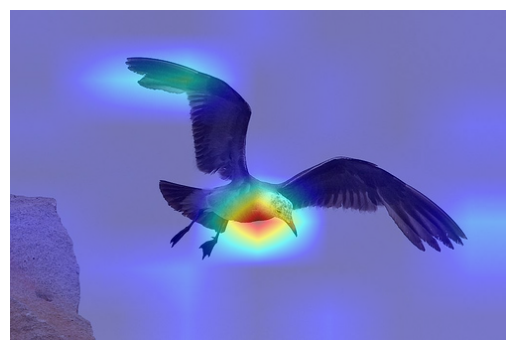

In [5]:
# -----------------------------
# Select one test image
# -----------------------------
image_no = 0
image, label, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 153
Predicted: 153


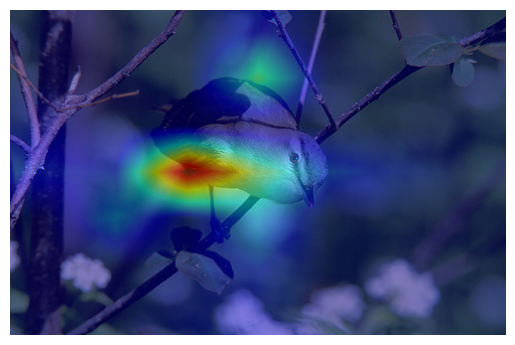

In [6]:
# -----------------------------
# Select one test image
# -----------------------------
image_no = 86
image, label, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 187
Predicted: 187
True label: 185
Predicted: 185
True label: 26
Predicted: 48
True label: 104
Predicted: 21
True label: 144
Predicted: 62
True label: 104
Predicted: 104
True label: 113
Predicted: 113


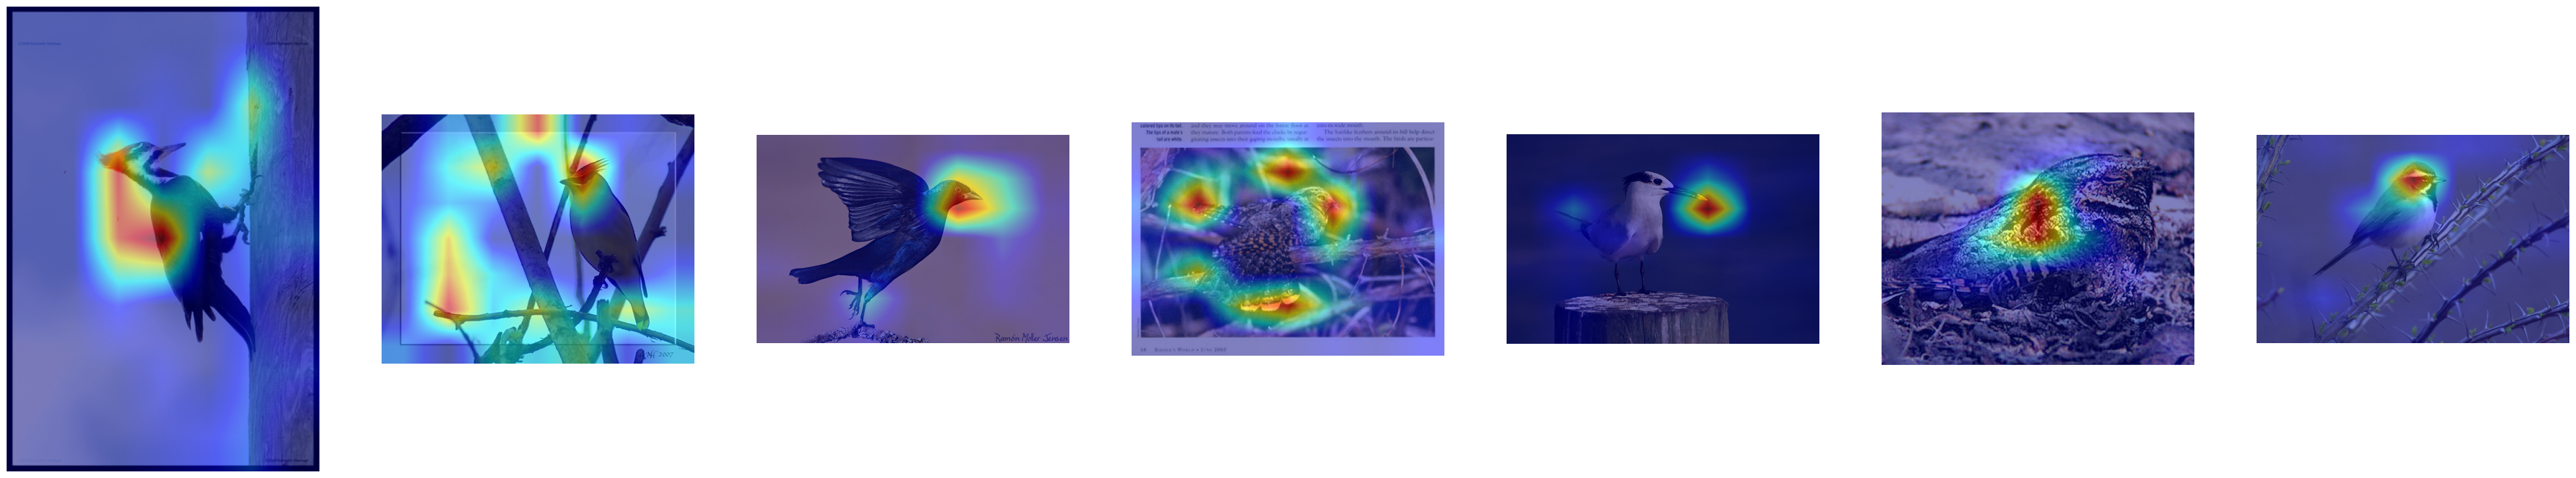

In [7]:
image_ids = [5,4,88,555,443,123,321]
num_images = len(image_ids)
fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=(50, 50*num_images))
for i,img_id in enumerate(image_ids):
    image, label, img_path = test_dataset[img_id]
    plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes[i])
plt.show()

In [9]:
# Load a different model
MODEL_NAME = "swin_base_patch4_window7_224.ms_in1k"
MODEL_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/swin_base_patch4_window7_224.ms_in1k_timm_logs/checkpoints/best_model.pth"
device = torch.device(DEVICE)
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=num_classes
)
state_dict = torch.load(MODEL_WEIGHTS, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=128, out_features=128, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU(approximate='none')
            (

In [10]:
# =========================================================
# 🔥 IMPORTANT PART FOR SWIN
# =========================================================
# Swin outputs tokens (B, N, C)
# We must reshape to (B, C, H, W)
def reshape_transform(tensor):
    # tensor is (B, H, W, C)
    return tensor.permute(0, 3, 1, 2)

# -----------------------------
# FinerCAM Setup
# Target layer: last Swin block
# -----------------------------
target_layers = [model.layers[-1].blocks[-1].norm1]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

True label: 187
Predicted: 187
True label: 185
Predicted: 185
True label: 26
Predicted: 48
True label: 104
Predicted: 104
True label: 144
Predicted: 146
True label: 104
Predicted: 104
True label: 113
Predicted: 113


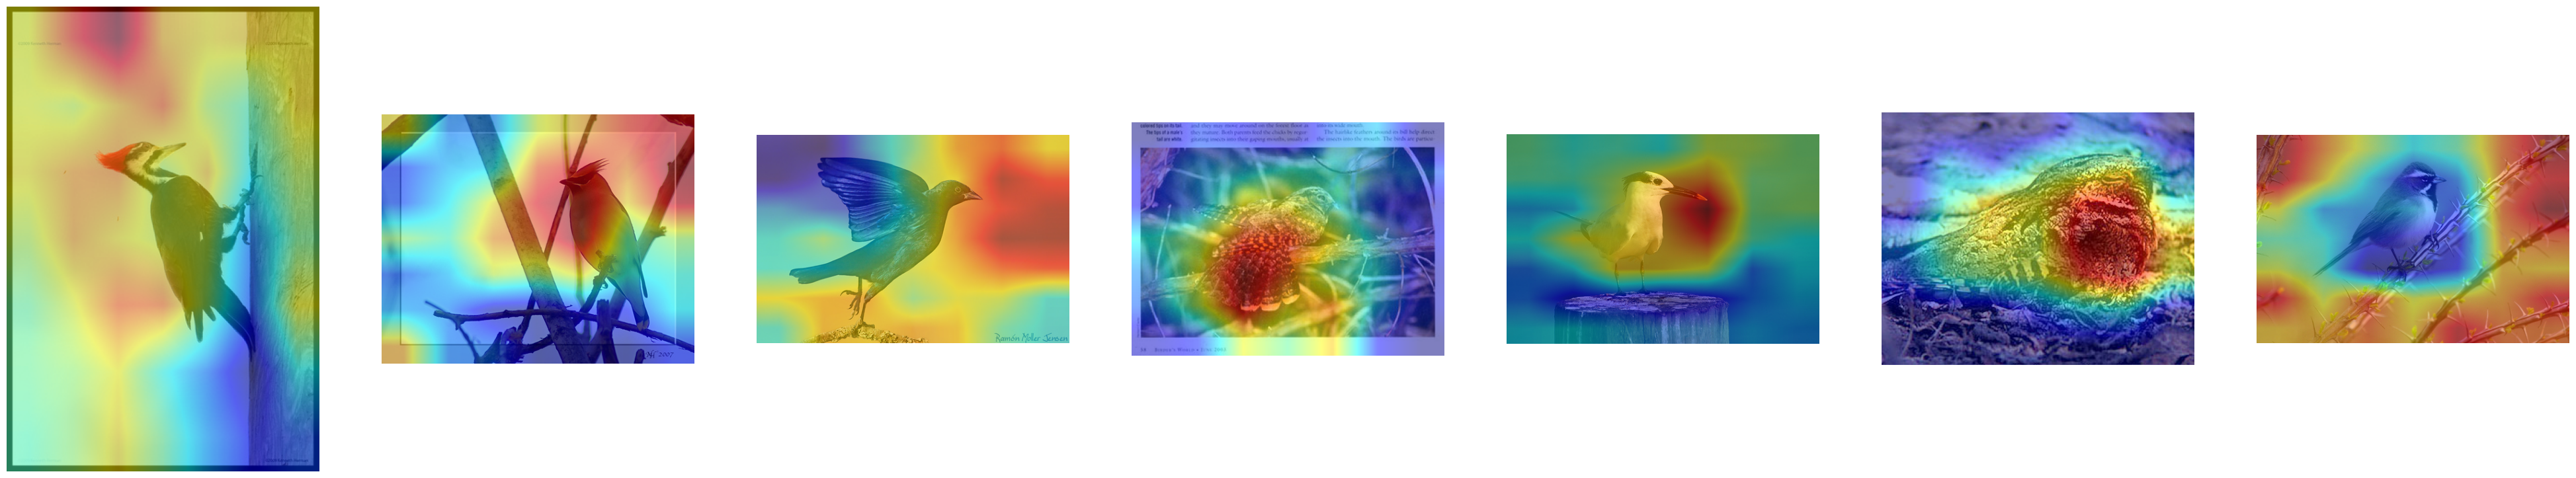

In [11]:
image_ids = [5,4,88,555,443,123,321]
num_images = len(image_ids)
fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=(50, 50*num_images))
for i,img_id in enumerate(image_ids):
    image, label, img_path = test_dataset[img_id]
    plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes[i])
plt.show()

In [12]:
# Load a different model
MODEL_NAME = r"deit_base_distilled_patch16_224.fb_in1k"
MODEL_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/deit_base_distilled_patch16_224.fb_in1k_timm_logs/checkpoints/best_model.pth"
device = torch.device(DEVICE)
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=num_classes
)
state_dict = torch.load(MODEL_WEIGHTS, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

VisionTransformerDistilled(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inpl

In [13]:
# -----------------------------
# 🔥 IMPORTANT: reshape for DeiT
# -----------------------------
def reshape_transform(tensor):
    # Remove CLS token if it exists
    if tensor.shape[1] == (int(tensor.shape[1] ** 0.5 + 0.5) ** 2) + 1:
        tensor = tensor[:, 1:, :]

    B, N, C = tensor.shape

    # Compute H and W dynamically
    H = W = int(N ** 0.5)
    if H * W != N:
        # Not perfect square → approximate rectangle
        H = int(N ** 0.5)
        W = int(np.ceil(N / H))
        if H * W != N:
            # Pad with zeros if necessary
            pad = H * W - N
            tensor = torch.cat([tensor, tensor.new_zeros(B, pad, C)], dim=1)

    tensor = tensor.reshape(B, H, W, C)
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

# -----------------------------
# FinerCAM Setup
# Target layer: (last block norm)
# -----------------------------
target_layers = [model.blocks[-1].norm1]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

True label: 187
Predicted: 187
True label: 185
Predicted: 185
True label: 26
Predicted: 48
True label: 104
Predicted: 104
True label: 144
Predicted: 146
True label: 104
Predicted: 21
True label: 113
Predicted: 113


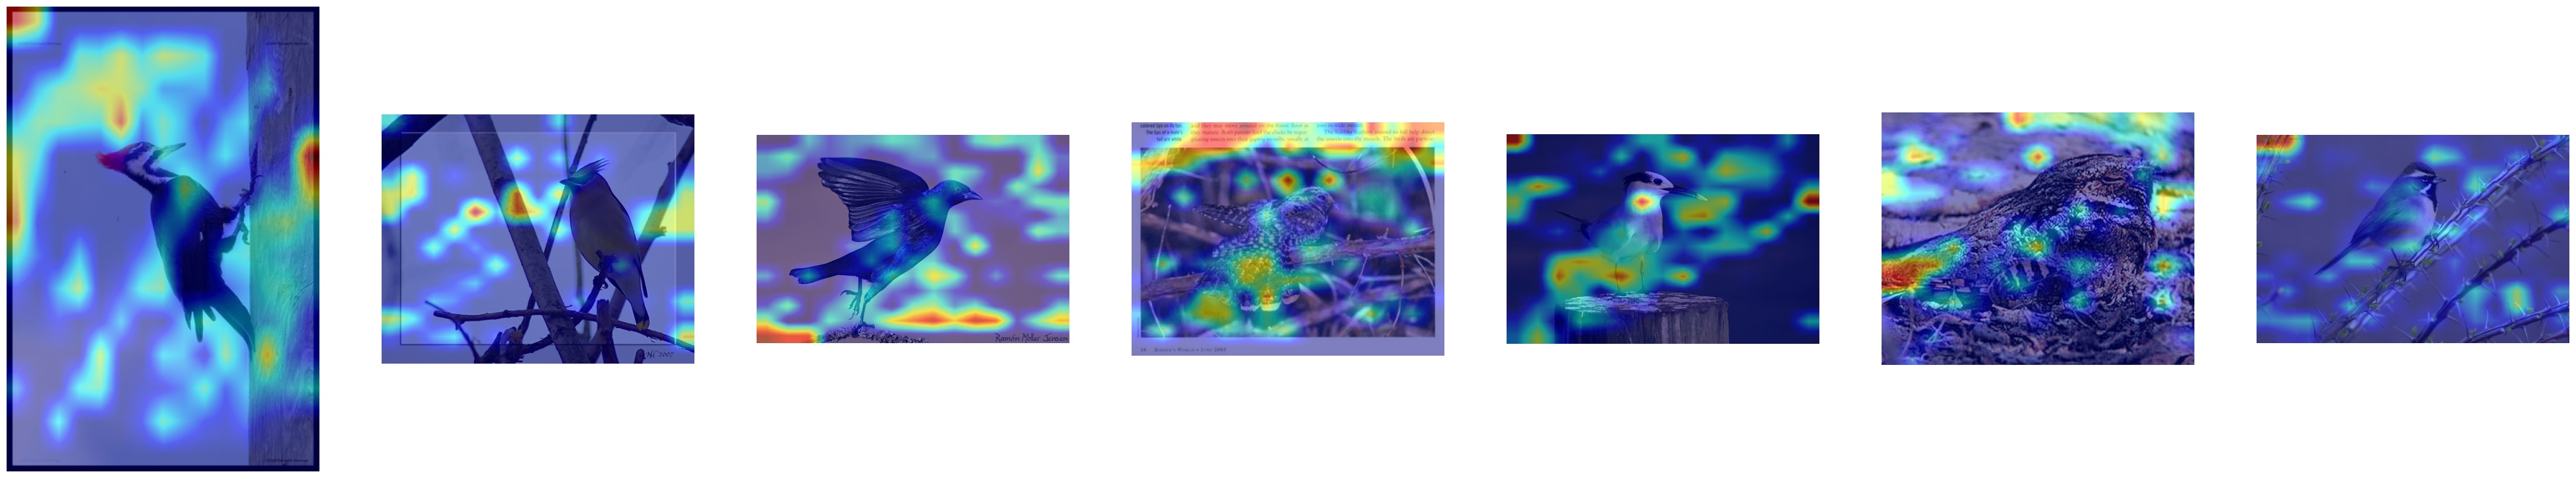

In [14]:
image_ids = [5,4,88,555,443,123,321]
num_images = len(image_ids)
fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=(50, 50*num_images))
for i,img_id in enumerate(image_ids):
    image, label, img_path = test_dataset[img_id]
    plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes[i])
plt.show()

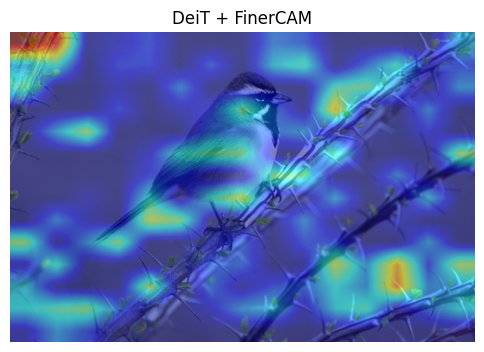

In [15]:
# =========================================================
# Minimal DeiT + FinerCAM Script (timm)
# =========================================================

import torch
import timm
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import FinerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------------
# CONFIG
# -----------------------------
MODEL_NAME = "deit_base_distilled_patch16_224.fb_in1k"
IMAGE_SIZE = 224
DEVICE = "cuda:0"

# -----------------------------
# Load model
# -----------------------------
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=num_classes
)

model.to(DEVICE)
model.load_state_dict(state_dict)
model.eval()

# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4925, 0.4475, 0.3490),
        std=(0.2392, 0.2265, 0.2213)
    )
])

# -----------------------------
# Load image
# -----------------------------
image_pil = Image.open(img_path).convert("RGB")
input_tensor = transform(image_pil).unsqueeze(0).to(DEVICE)

def reshape_transform(tensor):
    # Remove CLS token if it exists
    if tensor.shape[1] == (int(tensor.shape[1] ** 0.5 + 0.5) ** 2) + 1:
        tensor = tensor[:, 1:, :]

    B, N, C = tensor.shape

    # Compute H and W dynamically
    H = W = int(N ** 0.5)
    if H * W != N:
        # Not perfect square → approximate rectangle
        H = int(N ** 0.5)
        W = int(np.ceil(N / H))
        if H * W != N:
            # Pad with zeros if necessary
            pad = H * W - N
            tensor = torch.cat([tensor, tensor.new_zeros(B, pad, C)], dim=1)

    tensor = tensor.reshape(B, H, W, C)
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

# -----------------------------
# Target layer (last block norm)
# -----------------------------
target_layers = [model.blocks[-1].norm1]

cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

targets = [ClassifierOutputTarget(label)]

# -----------------------------
# Generate CAM
# -----------------------------
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

# -----------------------------
# Resize to original image
# -----------------------------
rgb_img = np.array(image_pil).astype(np.float32) / 255.0

grayscale_cam = cv2.resize(
    grayscale_cam,
    (rgb_img.shape[1], rgb_img.shape[0])
)

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.title("DeiT + FinerCAM")
plt.axis("off")
plt.show()